## With Glasser/_uniqueHemi Parcellation

--> compare with funcConnectome results (parietal_patterns.gradients_noHalo.rep_groupDiffs_02 ) !? as sanity check? ()

Glasser_hemiUnique
Weird:
- no connections between hemispheres? Corpus callosum not tracked?


In [1]:
import nilearn
import numpy as np
import pandas as pd
import os
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import os.path as op

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'

base_folder = op.join(bids_folder, 'derivatives' ,'dwi_connectome')
plot_folder = op.join(bids_folder, 'plots_and_ims', 'DTI')

subList = [f'{i:02d}' for i in range(1, 67)]
sub_array= np.array([int(i) for i in subList]) 

bids_folder_orig ='/mnt_03/ds-dnumrisk' 
df_participants = pd.read_csv(op.join(bids_folder_orig, 'add_tables','subjects_recruit_scan_scanned-final.csv'), header=0) #, index_col=0
group_list = df_participants.loc[:,['subject ID','group']].rename(mapper={'subject ID': 'subject'},axis=1).dropna().astype({'subject': int, 'group': int}).set_index('subject')
group_list = group_list#.reset_index()


In [4]:
from numrisk.fmri_analysis.gradients.utils import get_glasser_parcels, get_glasser_CAatlas_mapping
mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

In [10]:
atlas = 'Glasser_hemiUnique' #'AAL3_amended' # 
CMs = []
for sub in subList:
    connectome_file = op.join(base_folder, f'sub-{sub}', 'processing', 'connectome', atlas , 'connectome.csv')
    connectome = pd.read_csv(connectome_file,header=None)
    mu_factor = pd.read_table(op.join(base_folder,f'sub-{sub}', 'processing', 'tractography/two_tissue/SIFT2_mu.txt'),header=None).values[0][0]

    C = np.array(connectome)
    C_scaled = (C + C.T) * mu_factor
    CMs.append(C_scaled)    

print(np.shape(CMs))

cms = np.array(CMs)

(66, 360, 360)


In [13]:
from scipy.stats import ttest_ind
N_nets = 12

mat_tstat = np.zeros([N_nets, N_nets])
mat_pvals = np.ones([N_nets, N_nets])
average_mean_BN_fc_strength = np.zeros([N_nets, N_nets])
for seed_net in np.unique(glasser_CAatlas_mapping['ca_network']):
    for target_net in np.unique(glasser_CAatlas_mapping['ca_network']):
        network_seed_indices = np.where(glasser_CAatlas_mapping['ca_network'] == seed_net)[0]
        network_target_indices = np.where(glasser_CAatlas_mapping['ca_network'] == target_net)[0]

        mean_BN_fc_strength = []
        for i,sub in enumerate(subList):
            cm = CMs[i]
            cm_fil = cm[np.ix_(network_seed_indices, network_target_indices)]
            #fc_cm_fil = np.mean(cm_fil,axis=1)
            mean_fc_cm_fil = np.mean(np.mean(cm_fil,axis=1)) 
            mean_BN_fc_strength.append(mean_fc_cm_fil)
        average_mean_BN_fc_strength[seed_net-1,target_net-1] = np.mean(mean_BN_fc_strength)
        
        df = pd.DataFrame(np.array(mean_BN_fc_strength), index=sub_array)
        df.index.name = 'subject'
        df = df.join(group_list).set_index('group',append=True)
        t_stat, p_val = ttest_ind(df.xs(0,0,'group'), df.xs(1,0,'group'), equal_var=False)  # Welch's t-test

        mat_tstat[seed_net-1,target_net-1] = t_stat[0]
        mat_pvals[seed_net-1,target_net-1] = np.round(p_val[0], 3)



Text(0.5, 1.1, 'Average Between network SC strength \n Glasser_hemiUnique')

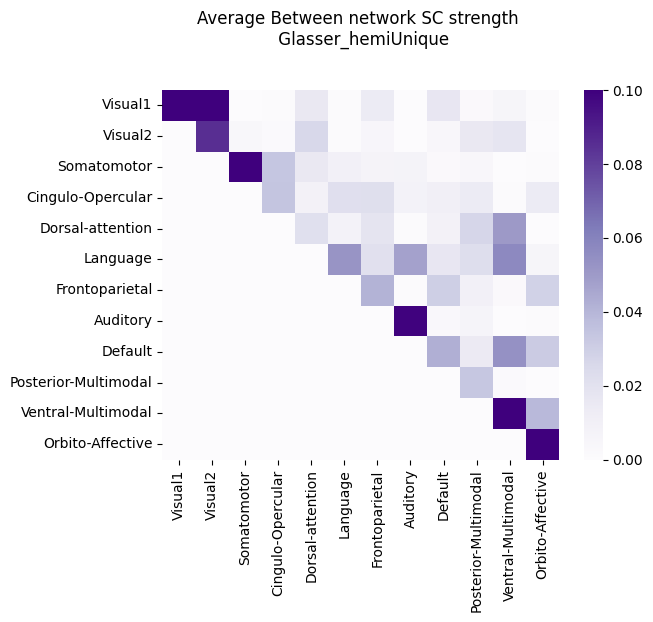

In [21]:
average_mean_BN_fc_strength[np.tril_indices_from(average_mean_BN_fc_strength, k=-1)] = 0

sns.heatmap(average_mean_BN_fc_strength, vmin=0,vmax=.1,cmap=  'Purples',# 'bwr',
            xticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)],
            yticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)])
plt.title(f'Average Between network SC strength \n {atlas}' , y=1.1)

NameError: name 'confspec' is not defined

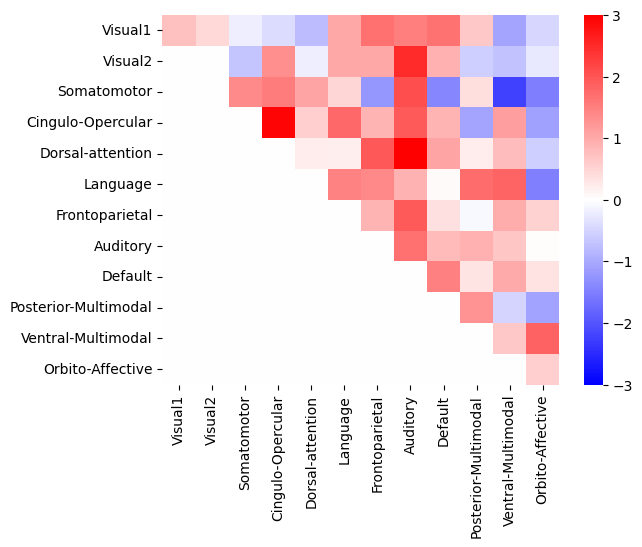

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

mat_tstat_ = mat_tstat.copy()
mat_tstat_[np.tril_indices_from(mat_tstat, k=-1)] = 0

sns.heatmap(mat_tstat_, cmap='bwr',vmin=-3,vmax=3,
            xticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)],
            yticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)])
plt.title(f'Between network FC strength (T-stat) \n {atlas}' , y=1.1)

Text(0.5, 1.02, 'P-vals of between group TTEst on between network FC strength \n ')

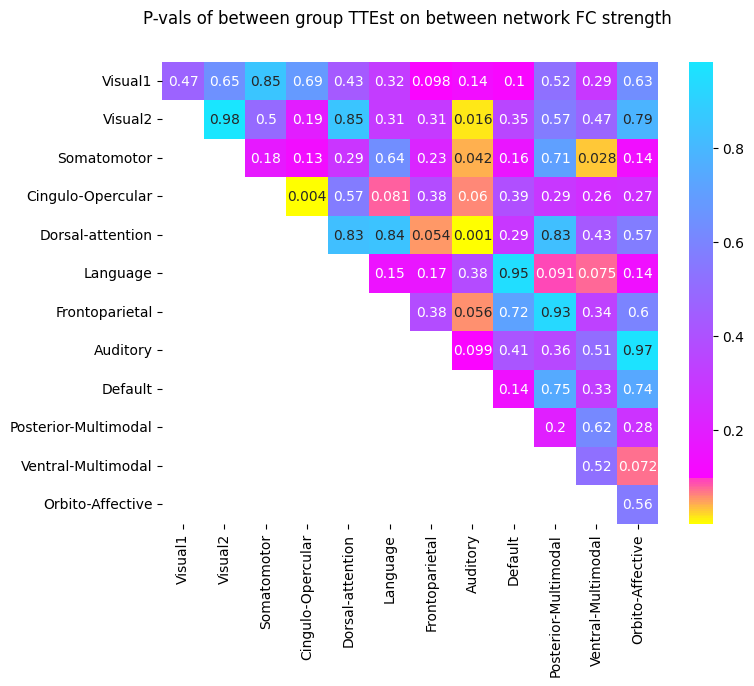

In [23]:
from numrisk.fmri_analysis.gradients.utils_02 import get_pval_colormap

pval_cmap = get_pval_colormap()

mat_pvals_ = mat_pvals.copy()
mat_pvals_[np.tril_indices_from(mat_pvals_, k=-1)] = np.nan

fig, axes = plt.subplots(1,1, figsize=(8,6)) 
sns.heatmap(mat_pvals_, cmap=pval_cmap,annot=True,ax=axes,#vmin=-0.4,vmax=0.4,
            xticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)],
            yticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)])
plt.title(f'P-vals of between group TTEst on between network FC strength \n ', y=1.02)